# Contents 

1. [Initialisation]

## 1. Initialisation

In [14]:
%matplotlib widget
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import qibo
from qibo import hamiltonians, set_backend, Circuit, symbols
from qibo.gates import Unitary
from qibo.symbols import *
set_backend("numpy")

[Qibo 0.2.22|INFO|2026-02-27 15:53:52]: Using numpy backend on /CPU:0


## 1.1 Define initial variables
[top](#Contents) 

Choose number of qubits and Hamiltonian

In [ ]:
#Number of qubits
L = 8

#Size of system
n = 2**L 
nsqrd = n**2
#Heisenberg Hamiltonian
H_def = sum([ Z(x)*Z(x+1) +X(x)*X(x+1) + Y(x)*Y(x+1)  for x in range(L-1)]) 
H_sh = hamiltonians.SymbolicHamiltonian(H_def)
H = H_sh.matrix
evals = sorted(np.linalg.eigvalsh(H))
eigvals, eigvecs = np.linalg.eigh(H)
ground_state = eigvecs[:, 0]

#minimum energy
target_energy = eigvals[0]
excited_energy = eigvals[1]
print("Ground state energy:", target_energy)
print("First excited state:", excited_energy)

gamma_high = 1.3
gamma_low = 0.0
mu_high = 1.0
mu_low = 0.0
scale = 100

[Qibo 0.2.22|WARNING|2026-02-27 15:53:52]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


Ground state energy: -13.499730394751552
First excited state: -11.928961951051539


### Choose initial state


In [16]:
def select_initial_state( init_type = None ):
    if init_type == "lowest energy":
        #basis vector with lowest energy
        es_ini = []
        for i in range(2**L):
            psi0 = np.zeros([1,2**L]).T
            psi0[i] = 1
            es_ini.append(H_sh.expectation(psi0.T[0]))
        min(es_ini)
        psi0 = np.zeros([1,2**L]).T
        psi0[np.argmin(es_ini)] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "last":
        #last basis vector
        psi0 = np.zeros([1,2**L]).T
        psi0[-1] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "first" or init_type is None:
        #first basis vector
        psi0 = np.zeros([1,2**L]).T
        psi0[0] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    
psi0, PSI0 = select_initial_state("lowest energy") 

## 1.2 Define Auxiliary Maths functions

In [17]:
def dotProd(A,B):
    #HS dot product, if A,B antihermitian then this is real
    return (1/2) * np.trace(A @ (B.conj().T)).real

def commutator(A,B):
    #Implement [A,B]
    return A @ B - B @ A

def dagger(A):
    return A.conj().T

def cost_func(U):
    #E = <psi|H|psi>
    return np.trace(dagger(U) @ H @ U @ PSI0).real

def compute_moments(U):
    #Compute expected value <H>, <H^2>, and variance
    E = cost_func(U)
    S = np.trace(dagger(U) @ H @ H @ U @ PSI0).real
    return [E, S, S - E**2]
compute_moments(np.eye(n))

[np.float64(-7.0), np.float64(77.0), np.float64(28.0)]

## Define Plotting Functions

In [18]:
def grid_plot(mus, gammas, energies):
    return

def heat_plot(mus, gammas, energies, title, points=[], xticks=[], yticks=[]):
    plt.figure()
    plt.rcParams["figure.autolayout"] = True
    plt.rcParams['text.usetex'] = True
    plt.pcolormesh(
    gammas, mus, energies,
    shading='nearest',
    cmap='RdBu')
    color_bar = plt.colorbar()
    
    for p in points:
        plt.plot(p["x"], p["y"], label=p["label"], marker=p["marker"], color='black', markersize=8)

        # Reference lines
        plt.axhline(p["y"], color='black', linewidth=1)
        plt.axvline(p["x"], color='black', linewidth=1)
        xticks.append(p["x"])
        yticks.append(p["y"])

    xticks.append(gammas[-1])
    yticks.append(mus[-1])
        
    plt.xticks(sorted(xticks))
    plt.yticks(sorted(yticks))
        
    ax = plt.gca()
    ax.tick_params(axis='both', labelsize=8)
    ax.tick_params(axis="x", labelrotation=90)

    plt.title(title)
    plt.xlim((0,gammas[-1]))
    plt.ylim((0,mus[-1]))
    plt.xlabel(r"$\gamma$")
    plt.ylabel(r"$\mu$")
    # plt.title(r"$f(e^{-\mu R_k -\gamma W_{k-1}})$")
    ax.legend(loc='best')
    plt.show()

def energy_geo_plot_all(U, directions):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True
    
    vals = np.linspace(mu_low, mu_high, scale)

    for dir in directions:
        energies = [compute_moments(expm(-val * dir["W"]) @ U)[0] for val in vals] 
        plt.plot(vals, energies, label=dir["label"])

    plt.xlabel("$\mu$")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.legend()
    plt.show()

def energy_geo_plot(x, y, title, points=[]):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True
    
    plt.plot(x, y)

    for p in points:
        plt.plot(p["x"], p["y"], label=p["label"], marker=p["marker"], color='black')
        # Reference lines
        plt.axhline(p["y"], color='black', linewidth=1)
        plt.axvline(p["x"], color='black', linewidth=1)


    plt.title(title)
    plt.xlabel("$\mu$")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.legend()
    plt.show()    
    
def iter_plot(data, var, title, hlines=[], yticks=[]):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True

    # for result in results:
    for datum in data:
        plt.plot(datum[var], label=datum["label"], marker=datum["marker"])

    #axes start and end
    # plt.xlim(0, data["iterations"]+2)
    plt.xlim(0, 15)
    
    #set ticks
    # plt.xticks(range(0,data["iterations"]+2))
    plt.xticks(range(0,16))
    
    plt.xlabel("step")
    plt.ylabel(var)
    plt.grid(True)
    # plt.axline((0, target_energy), (data["iterations"]+1,target_energy), label=f"$E_* = {np.round(target_energy,2)}$", linestyle = ":" )
    
    for line in hlines:
        plt.axline((0, line["mark"]), (15, line["mark"]), label=line["label"], linestyle = ":" )
        yticks.append(np.round(line["mark"], 2))

    plt.title(title)
    plt.yticks(sorted(yticks))
    plt.legend()
    plt.show()

def group_comm_plot(U, W, phi, title, vlines=[], hlines=[], mu_upper=mu_high):
    plt.figure()
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True

    yticks = []
    vals = np.linspace(mu_low, mu_upper, scale)
    group_comm_energies = []
    energies = [compute_moments(expm(-val * W) @ U)[0] for val in vals] 

    for num in [1,2,4]:
        group_comm_energies = [compute_moments(np.linalg.matrix_power(expm(1j * np.sqrt(val/num) * H)@ expm(1j *np.sqrt(val/num)*phi)@ expm(-1j*np.sqrt(val/num)*H) @ expm(-1j * np.sqrt(val/num) * phi), num) @ U)[0] for val in vals]
        plt.plot(vals, group_comm_energies, label=f"cost along group commutator with r={num}")

    plt.plot(vals, energies, label="cost along geodesic")
    
    for line in vlines:
        plt.axline((line["mark"], 0), (line["mark"], 0.5), label=line["label"], linestyle = ":" )

    for line in hlines:
        plt.axline((mu_low, line["mark"]), (mu_upper, line["mark"]), label=line["label"], linestyle = ":" )
    
    yticks.append(line["mark"])
    yticks += [np.ceil(line["mark"]).astype(int), np.ceil(line["mark"]).astype(int)/4, np.ceil(line["mark"]).astype(int)/2, 3*np.ceil(line["mark"]).astype(int)/4, 0]

    yticks.append(energies[0])
    plt.yticks(np.round(sorted(yticks),2))
    plt.xlim(left=0)
    plt.title(title)
    plt.xlabel(r"$\mu$")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.legend()
    plt.show() 



<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_24508/250941337.py:66: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$")
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_24508/250941337.py:100: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$")


## Define $\mu$, $\gamma$ selectors

In [19]:
def mu_line_search(dArgs):
    # dArgs = {"type": algo type, "Us": unitaries, "Ws": search directions, "title": plot title, 
    #          "num": GCI num, "PHIs": list of phis from [H, phi_k]}
    new_mu_high = dArgs["mu_high"][dArgs["iteration"]] if "mu_high" in dArgs else mu_high
    vals = np.linspace(mu_low, new_mu_high, scale)

    if dArgs["type"] == "DBI":
        energies = [compute_moments(expm(-val * dArgs["Rs"][-1]) @ dArgs["Us"][-1])[0] for val in vals]
        
    elif dArgs["type"] == "GCI" or dArgs["type"] == "TGCI":
        energies = [compute_moments(np.linalg.matrix_power(expm(1j * val * H) @ 
                                  expm(1j * val * dArgs["PSIs"][-1]) @ 
                                  expm(-1j * val * H) @ 
                                  expm(-1j * val * dArgs["PSIs"][-1]), dArgs["num"]) @ dArgs["Us"][-1])[0] for val in vals]
    elif dArgs["type"] == "TGCI2":
        new_mu_high = dArgs["mu_high"] if "mu_high" in dArgs else mu_high
        varphi = 1/2 * (np.sqrt(5) - 1)
        energies = [compute_moments(np.linalg.matrix_power(expm(1j * val * varphi * H) @ 
                                  expm(1j * val * dArgs["PSIs"][-1]) @ 
                                  expm(-1j * val * (varphi+1) * H) @ 
                                  expm(-1j * val * (1-varphi) * dArgs["PSIs"][-1]) @ expm(1j * val * H), dArgs["num"]) @ dArgs["Us"][-1])[0] for val in vals]
    else:
        raise ValueError("Unknown algorithm type")
    
    ind = np.argmin(energies)
    energy_geo_plot(vals, energies, dArgs["title"], points=[{"x":vals[ind], "y":energies[ind], "label": rf"$E_{{\mathrm{{min}}}} = {np.round(energies[ind],2)}$", "marker":"x"}])

    if dArgs["type"] == "DBI":
        return (vals[ind], 0)
    
    elif dArgs["type"] == "GCI" or dArgs["type"] == "TGCI" or dArgs["type"] == "TGCI2":
        return (dArgs["num"]*vals[ind]*vals[ind], 0)

    else:
        raise ValueError("Unknown algorithm type")

def mu_poly_approx(type, U, W, prevW=0, q=2, p=5):
    if np.size(prevW)!=1:
        W = W[0]
    #Find highest magnitude eigenvalue of S and compute respective period
    abs_omega_max = max(np.abs(np.linalg.eigvalsh(1j*W)))
    T_mu = (2 * np.pi) / (q * abs_omega_max)
    #Points where we sample the derivative
    mus = [i * (T_mu/p) for i in range(0,p+1)]
    #Points along geodesic where we sample the derivaive
    cost_values = []
    cost_values.append(np.eye(n))
    cost_values.append(expm(-(T_mu/p) * W))

    for i in range(2, p+1):
        cost_values.append(cost_values[i-1] @ cost_values[1])

    #Sample derivative
    cost_prime_samples = [-2*np.trace(H @ val @ U @ 
                                           PSI0 @ dagger(U) @ dagger(val) @ dagger(W) ).real for val in cost_values]

    #Matrix of polynomial terms
    mu_mat = [[mu**m for m in range(1, p+1)] for mu in mus[1::]]
    mu_mat = np.array(mu_mat)
    a_0 = cost_prime_samples[0]
    #Vector f(mu_i) - a_0
    v = np.array([val - a_0 for val in cost_prime_samples[1::]])
    #Compute polynomial coefficients
    a_i = np.linalg.inv(mu_mat) @  v
    # print("poly coeffs:", [a_0] + a_i.tolist())
    # input()

    #Find roots of polynomial
    coeffs = [a_0] + a_i.tolist()
    # print("reversed poly coeffs:", coeffs[::-1])
    # input()
    
    roots = np.roots(coeffs[::-1])

    #Filter non-positive roots

    # print("poly roots:", roots)
    # input()
    positive_roots = roots[np.abs(roots.imag) < 1e-12].real
    positive_roots = positive_roots[positive_roots>0].tolist()

    # print("positive poly roots:", positive_roots)
    # input()

    if np.size(prevW)==1:
       
        if len(positive_roots) > 0:
            return min(positive_roots)
        else:
            return 0
    else: #implement SD by always returning gamma = 0
        if len(positive_roots) > 0:
            return (min(positive_roots),0)
        else:
            return (0,0)

def mu_gamma_grid_search(dArgs):
    
    mu_vals = np.linspace(mu_low, dArgs["mu_high"][dArgs["iteration"]], scale)
    
    gamma_vals = np.linspace(gamma_low, dArgs["gamma_high"][dArgs["iteration"]], scale)

    if dArgs["type"] == "DBI":
        energies = [[ compute_moments(expm(-y * dArgs["Rs"][-1] -x * dArgs["Ws"][-1]) @ dArgs["Us"][-1] )[0] for x in gamma_vals ] for y in mu_vals]

    elif dArgs["type"] == "GCI":
        
        PSIk = dArgs["Us"][-1] @ PSI0 @ dagger(dArgs["Us"][-1])
        energies = [[ compute_moments(np.linalg.matrix_power(expm(1j * y * H) @ 
                                  expm(1j * (y * PSIk + x * dArgs["PHIs"][-1])) @ 
                                  expm(-1j * y * H) @ 
                                  expm(-1j * (y * PSIk + x * dArgs["PHIs"][-1])), dArgs["num"]) @ dArgs["Us"][-1])[0] for x in gamma_vals ] for y in mu_vals]
    
    elif dArgs["type"] == "TGCI" or dArgs["type"] == "TGCI2":
        energies = []
        trotter_n = dArgs["trotter n"]

        varphi = 0 if dArgs["type"] == "TGCI" else 1/2 * (np.sqrt(5) - 1)

        for y in mu_vals:
            row = []
            for x in gamma_vals:
                
                pos_trotterised_exp = np.eye(n)
                neg_trotterised_exp = np.eye(n)


                for i in range(1, dArgs["iteration"]):
                    c = float(np.prod(dArgs["gammas"][i::]))
                    pos_trotterised_exp = expm(1j * (x / trotter_n) * c * dArgs["PSIs"][i-1]) @ pos_trotterised_exp
                    neg_trotterised_exp = expm(-1j * (x / trotter_n) * c * (1-varphi) * dArgs["PSIs"][i-1]) @ neg_trotterised_exp

                pos_trotterised_exp = expm(1j * (x / trotter_n) * dArgs["PSIs"][dArgs["iteration"]-1]) @ pos_trotterised_exp
                pos_trotterised_exp = expm(1j * (y / trotter_n) * dArgs["PSIs"][dArgs["iteration"]]) @ pos_trotterised_exp
                neg_trotterised_exp = expm(-1j * (x / trotter_n) * (1-varphi) * dArgs["PSIs"][dArgs["iteration"]-1]) @ neg_trotterised_exp
                neg_trotterised_exp = expm(-1j * (y / trotter_n) * ((1-varphi)) * dArgs["PSIs"][dArgs["iteration"]]) @ neg_trotterised_exp

                pos_trotterised_exp = np.linalg.matrix_power(pos_trotterised_exp, dArgs["trotter n"])
                neg_trotterised_exp = np.linalg.matrix_power(neg_trotterised_exp, dArgs["trotter n"])

                if dArgs["type"] == "TGCI":
                    value = np.linalg.matrix_power(expm(1j * y * H) @ pos_trotterised_exp @ expm(-1j * y * H) @ neg_trotterised_exp, dArgs["num"]) @ dArgs["Us"][-1]
                elif dArgs["type"] == "TGCI2":
                    value = np.linalg.matrix_power(expm(1j * y * varphi * H) @ pos_trotterised_exp @ expm(-1j * y * (varphi+1) * H) @ neg_trotterised_exp @ expm(1j * y * H), dArgs["num"]) @ dArgs["Us"][-1]
                
                row.append(compute_moments(value)[0])
            
            energies.append(row)
        
    else:
        raise ValueError("Unknown algorithm type")
    
    # upper_mu_min = float(input("Enter upper mu limit for searching minimum: "))
    # upper_gamma_min = float(input("Enter upper gamma limit for searching minimum: "))

    # if type == "GCI":
    #     upper_mu_ind = np.floor(((upper_mu_min - mu_low)/(new_mu_high - mu_low)) * (scale-1)).astype(int)
    # else:
    #     upper_mu_ind = np.floor(((upper_mu_min - mu_low)/(mu_high - mu_low)) * (scale-1)).astype(int)

    # upper_gamma_ind = np.floor(((upper_gamma_min - gamma_low)/(gamma_high - gamma_low)) * (scale-1)).astype(int)
    
    # reduced_energies = [[energy for energy in record[:upper_mu_ind+1]] for record in energies[:upper_gamma_ind+1]]

    ind = np.argmin(energies)
    row, col = np.unravel_index(ind, np.array(energies).shape)

    mu_min = mu_vals[row]
    gamma_min = gamma_vals[col]

    
    heat_plot(mu_vals, gamma_vals, energies, dArgs["title"], 
              points=[{"x":gamma_min, "y":mu_min, "label":rf"$E_{{\mathrm{{min}}}} = {np.round(energies[row][col],2)}$", "marker":"o"}],
              xticks=list(np.round(gamma_vals[::20],2)), yticks=list(np.round(mu_vals[::20],2)))

    if mu_vals[row] == 0:
        return (0,0)
    else:
        if dArgs["type"] == "DBI":
            return (mu_min, gamma_min/mu_min)
        
        elif dArgs["type"] == "GCI" or dArgs["type"] == "TGCI" or dArgs["type"] == "TGCI2":
            return (dArgs["num"]*mu_min*mu_min, gamma_min/mu_min)

def gamma_PR(R, prevR):
    return dotProd(R- prevR, R) / dotProd(prevR, prevR)

def mu_gamma_auto_PR(U, Rs, prevW, q=2, p=3):
    gamma = gamma_PR(Rs[0], Rs[1])
    mu = mu_poly_approx(U, Rs[0] + gamma * prevW)
    return (mu, gamma)

def mu_line_gamma_PR(type, U, Rs, prevW, title, PHI=None):

    gamma = gamma_PR(Rs[0], Rs[1])


    mu = mu_line_search(type, U, Rs[0] + gamma*prevW, PHI= U @ PSI0 @ dagger(U) + gamma*PHI)

    return (mu, gamma)
    
    

## Descent Algorithm

In [20]:
def descent_algorithm(type, mu_selector, mu_gamma_selector, mu_highs, gamma_highs, label, marker, trotter_n=1, num=1, initial_U=np.eye(n).astype(complex), iterations=15, tolerance=0.01):
    PHI = (initial_U@PSI0@dagger(initial_U)).astype(complex)
    R = commutator(H, PHI) #Riemannian gradient

    

    RdotR = dotProd(R,R) #Size of gradient. If 0, U is a minimum
    energies = []
    variances = []
    mu_mins = []
    gamma_mins = [0]

    moments = compute_moments(initial_U)

    energies.append(moments[0])
    variances.append(moments[2])

    if RdotR < tolerance:
        return {"energies": energies, "variances": variances, "iterations": k, "mus": mu_mins, "gammas": gamma_mins, "label":label, "marker": marker}
    
    #Take a SD step

    W = R #intial search direction 

    Ws = [R] # list of search directions
    PHIs = [PHI] # list of phi_k from [H,phi_k]
    PSIs = [PSI0] # list of PSIks
    Rs = [R] # list of Riemannian gradients
    Us = [initial_U] # list of unitaries
    magnitudes = [np.trace(PSI0)]   

    SD_step_args = {"type": type, "Us": Us, "Ws": Ws, "PHIs": PHIs, 
                    "PSIs": PSIs, "Rs": Rs, "mu_high": mu_highs, "gammas": gamma_mins, "num": num, "trotter n": 1, "iteration": 0, "title": f"{label} initial SD step"}

    mu_min, _ = mu_selector(SD_step_args) 
    mu_mins.append(mu_min)

    # Have selected mu (step size) above
    fidelity = np.abs(dagger(ground_state) @ initial_U @ psi0)**2
    fidelities = [fidelity]

    if type == "DBI":
        # Compute unitary minimising cost along geodesic
        U = expm(-mu_min*W)@initial_U
    
    elif type == "GCI" or type == "TGCI":
        # Approximate unitary minimising cost along geodesic
        U = np.linalg.matrix_power(expm(1j * np.sqrt(mu_min/num) * H) @ 
                                  expm(1j * np.sqrt(mu_min/num) * PHI) @ 
                                  expm(-1j * np.sqrt(mu_min/num) * H) @ 
                                  expm(-1j * np.sqrt(mu_min/num) * PHI), num) @ initial_U

    elif type == "TGCI2":
        varphi = 1/2 * (np.sqrt(5) - 1)
        U = np.linalg.matrix_power(expm(1j * np.sqrt(mu_min/num) * varphi * H) @ 
                                  expm(1j * np.sqrt(mu_min/num) * PHI) @ 
                                  expm(-1j * np.sqrt(mu_min/num) * (varphi+1) * H) @ 
                                  expm(-1j * np.sqrt(mu_min/num) * (1-varphi) * PHI) @ 
                                  expm(1j * np.sqrt(mu_min/num)*H), num) @ initial_U
    else:
        raise(ValueError("Unknown descent algorithm type"))
   

    moments = compute_moments(U)
    energies.append(moments[0])
    variances.append(moments[2])

    #Take CG steps
    k=1
   
    PSIk = U@PSI0@dagger(U) # PSI1
    R = commutator(H, PSIk) # Riemannian gradient [H, PSI1]
    RdotR = dotProd(R,R)

    
    PSIs.append(PSIk) # add PSI1
    Rs.append(R) # add [H, PSI1]
    Us.append(U) # add U1
    magnitudes.append(np.trace(PSIk))
    #Missing PHI1 and W1
    
    fidelity = np.abs(dagger(ground_state) @ U @ psi0)**2
    fidelities.append(fidelity)

    while RdotR > tolerance and k < iterations and fidelity < 0.9:
        CG_step_args = {"type": type, "Us": Us, "Ws": Ws, "PHIs": PHIs, 
                    "PSIs": PSIs, "Rs": Rs, "gammas": gamma_mins, "num": num, 
                    "trotter n": trotter_n, "iteration": k, "mu_high": mu_highs, "gamma_high": gamma_highs, "title": f"{label} iteration {k}"}
        
        mu_min, gamma_min = mu_gamma_selector(CG_step_args) #select mu and gamma

        if mu_min < 1e-12:
            break

        gamma_mins.append(gamma_min)
        mu_mins.append(mu_min)

        PHI = PSIk + gamma_min * PHI
        W = R + gamma_min*Ws[-1] #CG search direction
        # W = [H, PHI] equivalent to above line
       
        if dotProd(W, R) < 0 and type == "DBI": #if W not a descent direction then make W = R
            print("Resetting search direction W at k =", k)
            W = R

        PHIs.append(PHI)
        Ws.append(W)

        if type == "DBI":
            U = expm(-mu_min*W) @ U

        elif type == "GCI":

            U = np.linalg.matrix_power(expm(1j * np.sqrt(mu_min/num) * H) @ 
                                      expm(1j * np.sqrt(mu_min/num)*PHI) @ 
                                      expm(-1j * np.sqrt(mu_min/num)*H) @ 
                                      expm(-1j * np.sqrt(mu_min/num) * PHI), num) @ U
        elif type == "TGCI" or type == "TGCI2":
            varphi = 0 if type == "TGCI" else 1/2 * (np.sqrt(5) - 1)
            pos_trotterised_exp = np.eye(n)
            neg_trotterised_exp = np.eye(n)
            x = np.sqrt(mu_min/num) * gamma_min
            y = np.sqrt(mu_min/num)
            for i in range(1, k):
                c = float(np.prod(gamma_mins[i:-1]))
                pos_trotterised_exp = expm(1j * (x / trotter_n) * c * PSIs[i-1]) @ pos_trotterised_exp
                neg_trotterised_exp = expm(-1j * (x / trotter_n) * c * (1-varphi) * PSIs[i-1]) @ neg_trotterised_exp

            pos_trotterised_exp = expm(1j * (x / trotter_n) * PSIs[k-1]) @ pos_trotterised_exp
            pos_trotterised_exp = expm(1j * (y / trotter_n) * PSIs[k]) @ pos_trotterised_exp
            neg_trotterised_exp = expm(-1j * (x / trotter_n) * (1-varphi) * PSIs[k-1]) @ neg_trotterised_exp
            neg_trotterised_exp = expm(-1j * (y / trotter_n) * (1-varphi) * PSIs[k]) @ neg_trotterised_exp

            pos_trotterised_exp = np.linalg.matrix_power(pos_trotterised_exp, trotter_n)
            neg_trotterised_exp = np.linalg.matrix_power(neg_trotterised_exp, trotter_n)

            if type == "TGCI":
                U = np.linalg.matrix_power(expm(1j * y * H) @ pos_trotterised_exp @ expm(-1j * y * H) @ neg_trotterised_exp, num) @ U
            elif type == "TGCI2":
                U = np.linalg.matrix_power(expm(1j * y * varphi * H) @ pos_trotterised_exp @ expm(-1j * y * (varphi+1) * H) @ neg_trotterised_exp @ expm(1j * y * H), num) @ U
        else:
            raise(ValueError("Unknown descent algorithm type"))
        
        moments = compute_moments(U)

        energies.append(moments[0])
        variances.append(moments[2])

        fidelity = np.abs(dagger(ground_state) @ U @ psi0)**2    
        fidelities.append(fidelity)

        PSIk = U@PSI0@dagger(U) # PSI_k
        R = commutator(H, PSIk) #new steepest descent direction

        Us.append(U)
        PSIs.append(PSIk)
        Rs.append(R)
        magnitudes.append(np.trace(PSIk))


        RdotR = dotProd(R,R)
        k += 1 
       
    print(label, "fidelity", fidelity[0])
    return {"unitaries": Us, "magnitudes": magnitudes, "velocities": Ws, "PHIs": PHIs, "energies": energies, "variances": variances, "fidelities":fidelities, "iterations": k, "mus": mu_mins, "gammas": gamma_mins, "label":label, "marker": marker}

## Get Data

In [21]:
print("target energy is", target_energy)
print("1st excited energy is", excited_energy)

target energy is -13.499730394751552
1st excited energy is -11.928961951051539


### Set parameter space

In [22]:
#################################################################################################

generic_mu_highs = [mu_high for _ in range(16)]
generic_gamma_highs = [gamma_high for _ in range(16)]   

grid_CG_mu_highs = generic_mu_highs.copy()
grid_CG_gamma_highs = generic_gamma_highs.copy()

grid_CG_mu_highs[0] = 0.5
grid_CG_gamma_highs[1] = 0.35

#################################################################################################

grid_GCI1_mu_highs = generic_mu_highs.copy()
grid_GCI1_gamma_highs = generic_gamma_highs.copy()

grid_GCI1_mu_highs[0] = 0.5
grid_GCI1_gamma_highs[1] = 1.5

grid_GCI1_gamma_highs[2] = 0.2

#################################################################################################

grid_TGCI_mu_highs = generic_mu_highs.copy()
grid_TGCI_gamma_highs = generic_gamma_highs.copy()

grid_TGCI_mu_highs[0] = 0.5

grid_TGCI_mu_highs[1] = 0.5
grid_TGCI_gamma_highs[1] = 2

grid_TGCI_gamma_highs[2] = 0.25

grid_TGCI_gamma_highs[3] = 2



#################################################################################################

grid_TGCI2_mu_highs = generic_mu_highs.copy()
grid_TGCI2_gamma_highs = generic_gamma_highs.copy()

grid_TGCI2_mu_highs[0] = 0.5

grid_TGCI2_mu_highs[2] = 1.0
grid_TGCI2_gamma_highs[2] = 0.3

#################################################################################################

grid_T2GCI_mu_highs = generic_mu_highs.copy()

grid_T2GCI_mu_highs[0] = 0.5
grid_T2GCI_mu_highs[1] = 0.5

#################################################################################################

grid_TGCIr2_mu_highs = generic_mu_highs.copy()

grid_TGCIr2_mu_highs[0] = 0.5

#################################################################################################

line_search_mu_highs = [0.5 for _ in range(16)]


###  Run Descent Algorithms

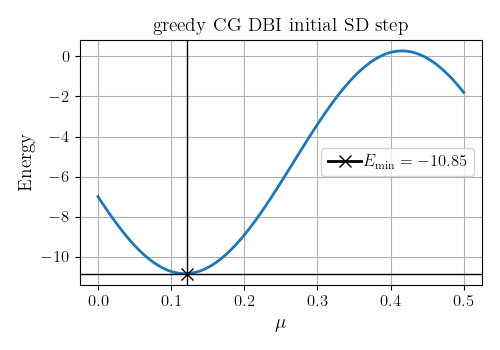

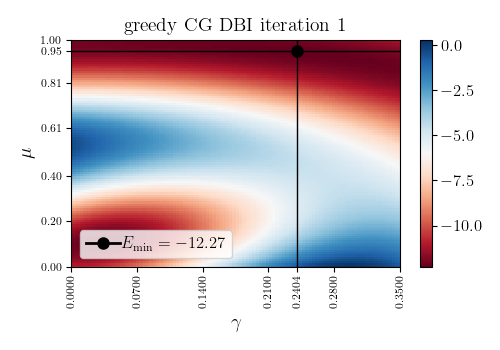

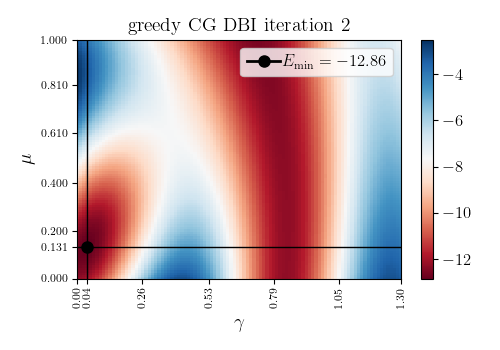

greedy CG DBI fidelity 0.6379577786818106


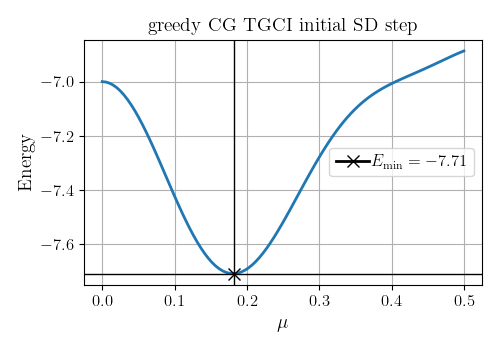

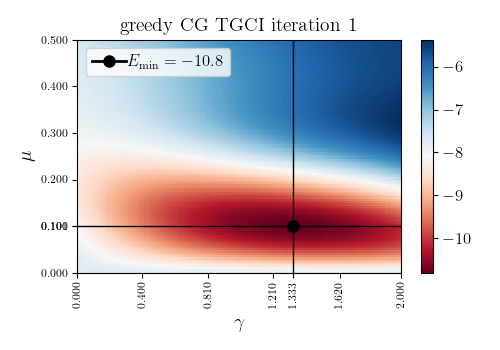

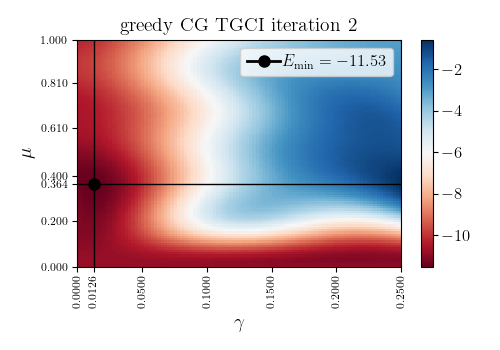

greedy CG TGCI fidelity 0.4165771098616621


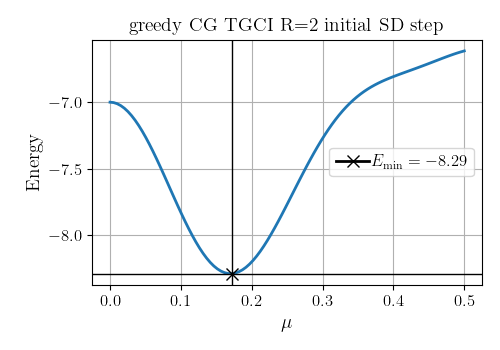

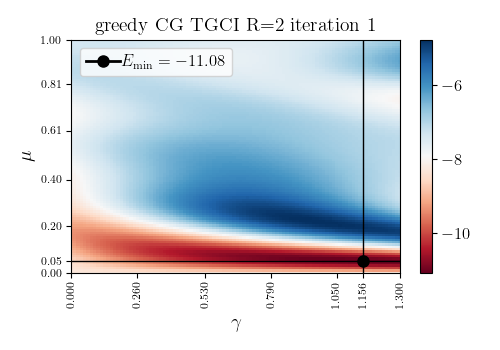

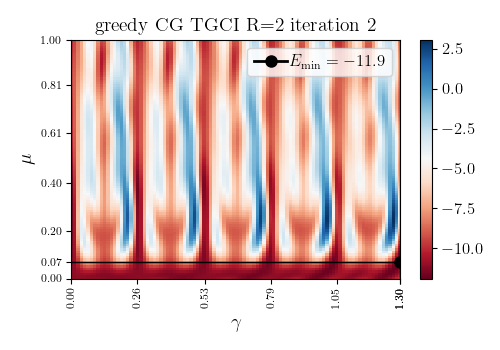

greedy CG TGCI R=2 fidelity 0.41046375239804894


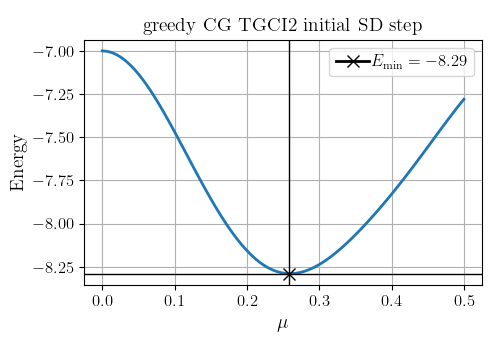

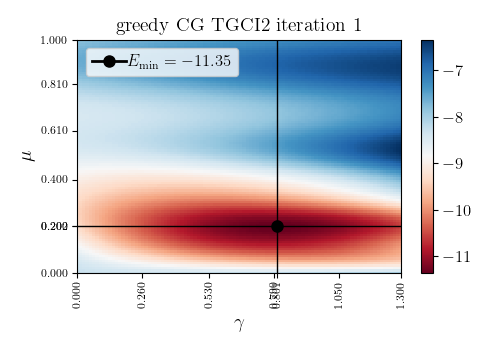

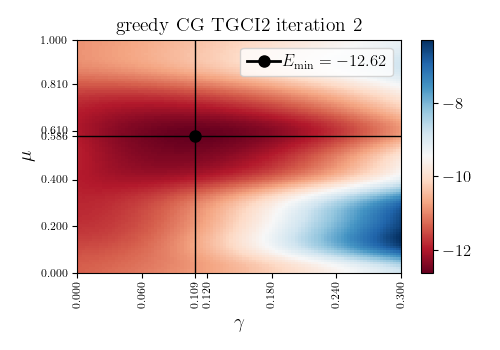

greedy CG TGCI2 fidelity 0.6315744737313003


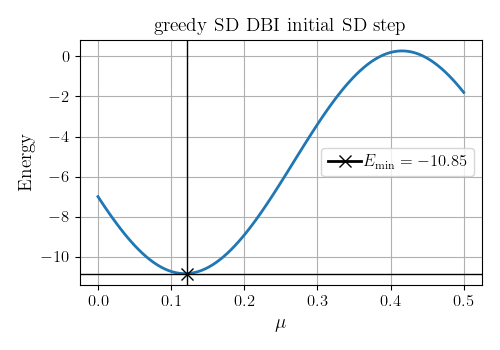

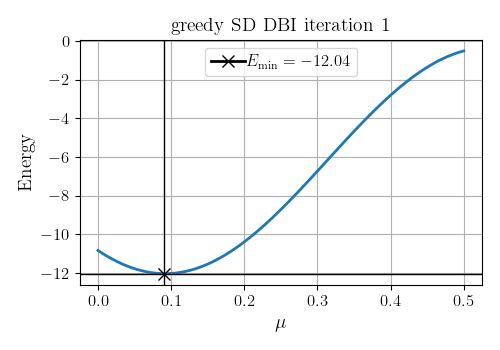

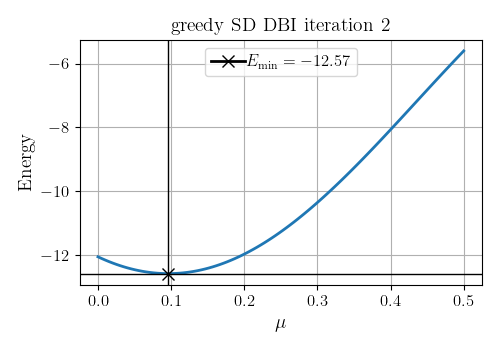

greedy SD DBI fidelity 0.5499610972107934


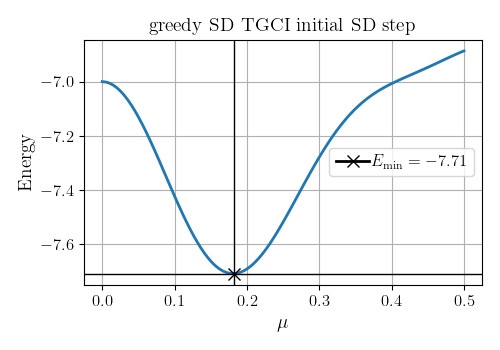

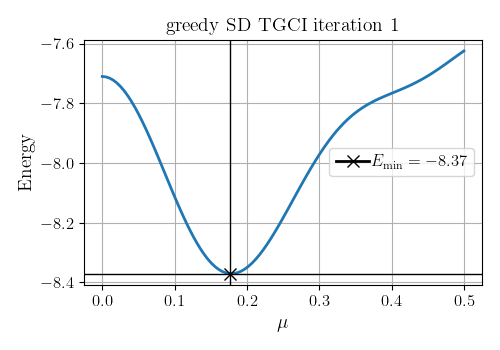

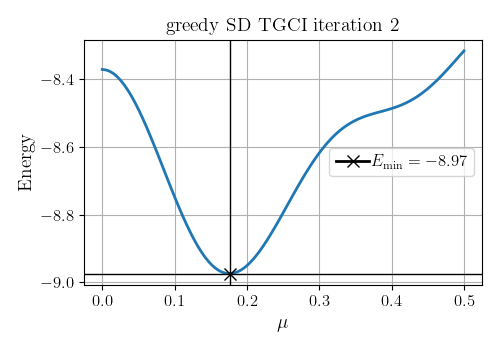

greedy SD TGCI fidelity 0.22186727162983896


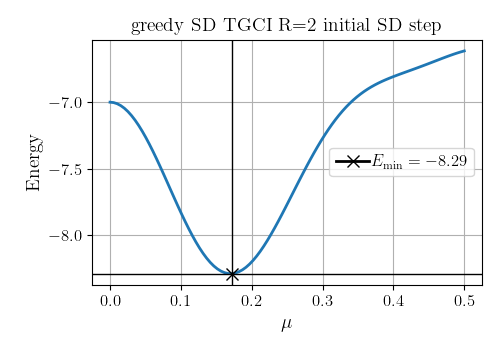

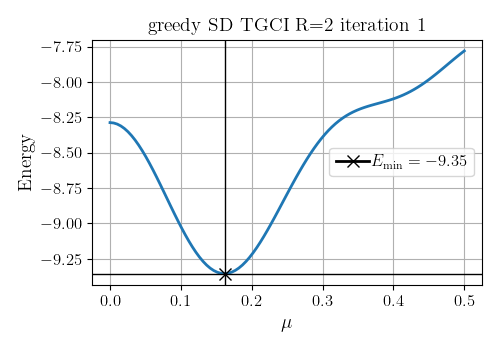

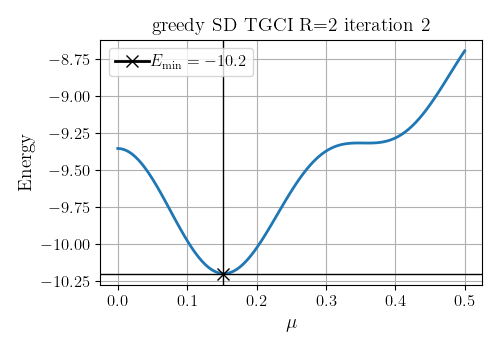

greedy SD TGCI R=2 fidelity 0.2994589143720553


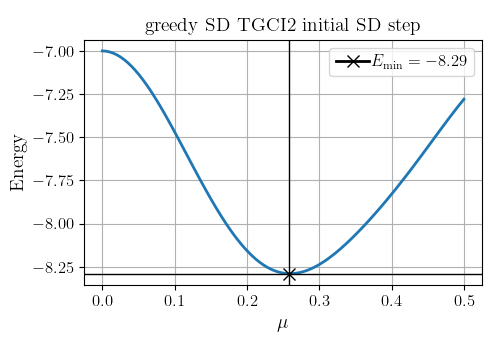

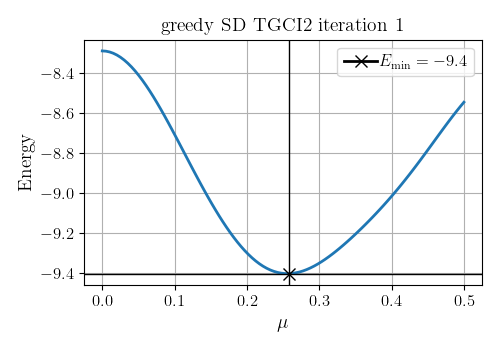

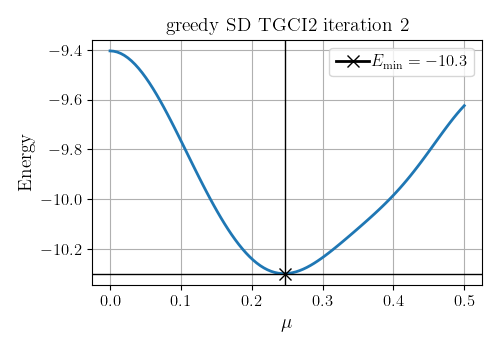

greedy SD TGCI2 fidelity 0.3124067198018673


In [ ]:
results = []


####################################################### CG algorithms #######################################################

grid_CG = descent_algorithm("DBI", mu_line_search, mu_gamma_grid_search, grid_CG_mu_highs, grid_CG_gamma_highs, "greedy CG DBI", "*", iterations=10)
grid_CG_TGCI = descent_algorithm("TGCI", mu_line_search, mu_gamma_grid_search, grid_TGCI_mu_highs, grid_TGCI_gamma_highs, "greedy CG TGCI", ">", num=1, iterations=10, trotter_n=1)
# grid_CG_T2GCI = descent_algorithm("TGCI", mu_line_search, mu_gamma_grid_search, grid_T2GCI_mu_highs, generic_gamma_highs, "greedy CG TGCI n=2", "<", num=1, iterations=6, trotter_n=2)
grid_CG_TGCIr2 = descent_algorithm("TGCI", mu_line_search, mu_gamma_grid_search, grid_TGCIr2_mu_highs, generic_gamma_highs, "greedy CG TGCI R=2", "^", num=2, iterations=10, trotter_n=1)
# grid_CG_T2GCIr2 = descent_algorithm("TGCI", mu_line_search, mu_gamma_grid_search, grid_TGCIr2_mu_highs, generic_gamma_highs, "greedy CG TGCI n=2, R=2", "v", num=2, iterations=6, trotter_n=2)
grid_CG_TGCI2 = descent_algorithm("TGCI2", mu_line_search, mu_gamma_grid_search, grid_TGCI2_mu_highs, grid_TGCI2_gamma_highs, "greedy CG TGCI2", "s", num=1, iterations=10, trotter_n=1)

results.append(grid_CG)
results.append(grid_CG_TGCI)
results.append(grid_CG_TGCI2)
results.append(grid_CG_TGCIr2)
# results.append(grid_CG_T2GCI)
# results.append(grid_CG_T2GCIr2)

####################################################### SD algorithms #######################################################

line_SD = descent_algorithm("DBI", mu_line_search, mu_line_search, line_search_mu_highs, generic_gamma_highs, "greedy SD DBI", "s", iterations=10)

line_SD_TGCI = descent_algorithm("TGCI", mu_line_search, mu_line_search, line_search_mu_highs, generic_gamma_highs, "greedy SD TGCI", "d", num=1, iterations=10, trotter_n=1)

line_SD_TGCIr2 = descent_algorithm("TGCI", mu_line_search, mu_line_search, line_search_mu_highs, generic_gamma_highs, "greedy SD TGCI R=2", "^", num=2, iterations=10, trotter_n=1)

line_SD_TGCI2 = descent_algorithm("TGCI2", mu_line_search, mu_line_search, line_search_mu_highs, generic_gamma_highs, "greedy SD TGCI2", "o", num=1, iterations=10, trotter_n=1) 

results.append(line_SD)
results.append(line_SD_TGCI)
results.append(line_SD_TGCI2)
results.append(line_SD_TGCIr2)

### Comparing DBI, GCI, and TGCI

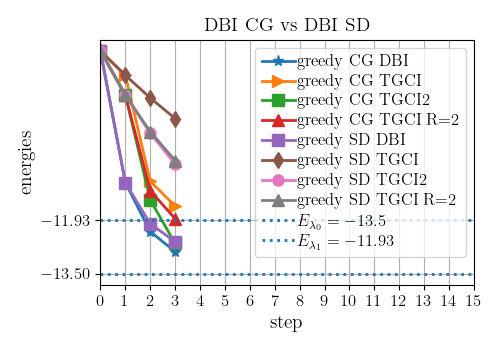

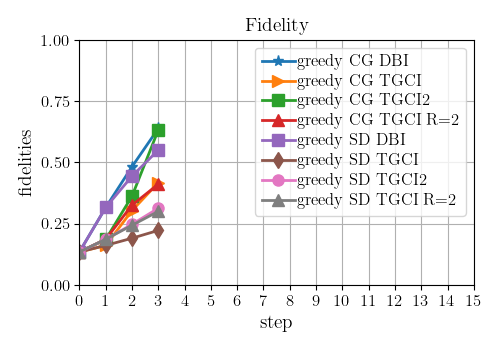

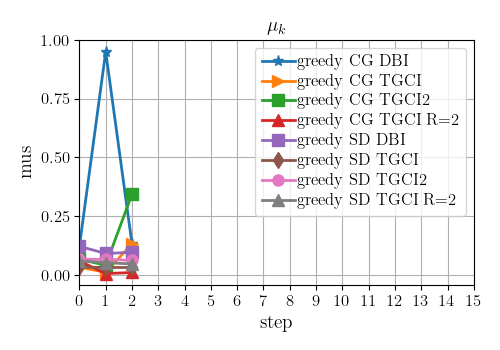

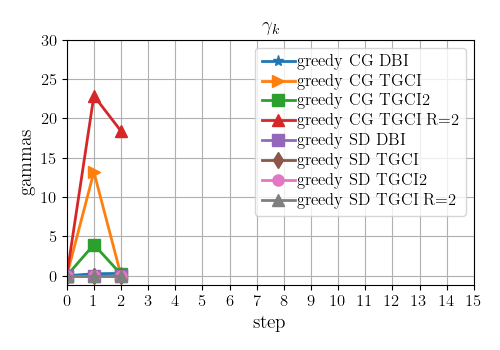

In [24]:
iter_plot(results, "energies", "DBI CG vs DBI SD", 
          hlines=[{"mark": target_energy, "label": rf"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"},
                                                  {"mark": excited_energy, "label": rf"$E_{{\lambda_1}} = {np.round(excited_energy,2)}$"}])

# iter_plot([grid_CG, grid_CG_GCI1, grid_CG_TGCI], "magnitudes", r"$\langle \psi_k | \psi_k \rangle$", yticks=[0, 0.25, 0.5,0.75,1])
iter_plot(results, "fidelities", r"Fidelity", yticks=[0, 0.25, 0.5,0.75,1])
iter_plot(results, "mus", r"$\mu_k$", yticks=[0,0.25,0.5,0.75,1])
iter_plot(results, "gammas", r"$\gamma_k$", yticks=[0,5,10,15,20,25,30])


### General

In [25]:
# print("target energy is", target_energy)


# grid_CG = descent_algorithm("DBI", mu_line_search, mu_gamma_grid_search, "greedy CG DBI", "*")

# # line_SD = descent_algorithm("DBI", mu_line_search, mu_line_search, "greedy SD DBI", "^")

# grid_CG_GCI1 = descent_algorithm("GCI", mu_line_search, mu_gamma_grid_search, "greedy CG GCI 1", "s", num=1, iterations=2)

# # line_SD_GCI1 = descent_algorithm("GCI", mu_line_search, mu_line_search, "greedy SD GCI 1", "o", num=1)

# # line_SD_GCI2 = descent_algorithm("GCI", mu_line_search, mu_line_search, "greedy SD GCI 2", ">", num=2)

# # line_SD_GCI4 = descent_algorithm("GCI", mu_line_search, mu_line_search, "greedy SD GCI 4", "p", num=4)

# grid_CG_GCI2 = descent_algorithm("GCI", mu_line_search, mu_gamma_grid_search, "greedy CG GCI 2", "v", num=2, iterations=2)

# grid_CG_GCI4 = descent_algorithm("GCI", mu_line_search, mu_gamma_grid_search, "greedy CG GCI 4", "<", num=4, iterations=2)



# # for i in range(grid_CG["iterations"]):
# #     phi = np.zeros([n,n], dtype=complex)
# #     c=1
# #     for j in range(i-1, -1,-1):
# #         c *= grid_CG["gammas"][j]
# #         phi +=  c * (grid_CG["unitaries"][j] @ PSI0 @ dagger(grid_CG["unitaries"][j]))
# #     phi += grid_CG["unitaries"][i]@PSI0@dagger(grid_CG["unitaries"][i])

# #     group_comm_plot(grid_CG["unitaries"][i], grid_CG["velocities"][i], phi, [1,2,4], i)
# # poly_SD = general_cg(mu_poly_approx, mu_poly_approx, "$\gamma_k = 0, \mu_k = \mu_\mathrm{poly}$", "p")
# # toplot.append(poly_SD)

# # auto_pr_CG = general_cg(mu_line_search, mu_gamma_auto_PR, "$\gamma_k = \gamma_\mathrm{PR}, \mu_k = \mu_\mathrm{poly}$", "s")
# # toplot.append(auto_pr_CG)

# # line_pr_CG = general_cg(mu_line_search, mu_line_gamma_PR, "$\gamma_k = \gamma_\mathrm{PR}, \mu_k = \mu_\mathrm{min}$", "o")
# # toplot.append(line_pr_CG)

# # plot energies
# iter_plot([grid_CG, line_SD], "energies", "DBI CG vs SD",hlines=[{"mark": target_energy, "label": rf"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"},
#                                                   {"mark": excited_energy, "label": rf"$E_{{\lambda_1}} = {np.round(excited_energy,2)}$"}])

# # iter_plot([grid_CG, grid_CG_GCI1, grid_CG_GCI2, grid_CG_GCI4], "energies", "GCI CG vs DBI CG", hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"},
#                                                   {"mark": excited_energy, "label": rf"$E_{{\lambda_1}} = {np.round(excited_energy,2)}$"}])

# iter_plot([line_SD, line_SD_GCI1, line_SD_GCI4], "energies", "GCI SD", hlines=[{"mark": target_energy, "label": rf"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"},
#                                                   {"mark": excited_energy, "label": rf"$E_{{\lambda_1}} = {np.round(excited_energy,2)}$"}])


# for x in range(grid_CG["iterations"]):
#     group_comm_plot(grid_CG["unitaries"][x], grid_CG["velocities"][x], grid_CG["PHIs"][x], f"Iteration {x} DBI CG", 
#                     vlines=[{"mark": grid_CG["mus"][x], "label": rf"$\mu_\mathrm{{min}} = {np.round(grid_CG["mus"][x],2)}$"}],
#                     hlines=[{"mark": target_energy, "label": rf"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}])

#     # group_comm_plot(line_SD["unitaries"][x], line_SD["velocities"][x], line_SD["PHIs"][x], f"Iteration {x} DBI SD", 
#     #                 vlines=[{"mark": line_SD["mus"][x], "label": f"$\mu_\mathrm{{min}} = {np.round(line_SD["mus"][x],2)}$"}],
#     #                 hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}])
# for x in range(grid_CG_GCI1["iterations"]):    
#     group_comm_plot(grid_CG_GCI1["unitaries"][x], grid_CG_GCI1["velocities"][x], grid_CG_GCI1["PHIs"][x], f"Iteration {x} GCI 1 CG", 
#                     vlines=[{"mark": grid_CG_GCI1["mus"][x], "label": rf"$\mu_\mathrm{{min}} = {np.round(grid_CG_GCI1["mus"][x],2)}$"}],
#                     hlines=[{"mark": target_energy, "label": rf"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}])

# for x in range(grid_CG_GCI1["iterations"]):    
#     group_comm_plot(grid_CG_GCI1["unitaries"][x], grid_CG_GCI1["velocities"][x], grid_CG_GCI1["PHIs"][x], f"Iteration {x} GCI 1 CG", 
#                     vlines=[{"mark": grid_CG_GCI1["mus"][x], "label": rf"$\mu_\mathrm{{min}} = {np.round(grid_CG_GCI1["mus"][x],2)}$"}],
#                     hlines=[{"mark": target_energy, "label": rf"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}], mu_upper=grid_CG_GCI1["mus"][x]*1.5)

#     # group_comm_plot(grid_CG_GCI2["unitaries"][x], grid_CG_GCI2["velocities"][x], grid_CG_GCI2["PHIs"][x], f"Iteration {x} GCI 2 CG", 
#     #                 vlines=[{"mark": grid_CG_GCI2["mus"][x], "label": f"$\mu_\mathrm{{min}} = {np.round(grid_CG_GCI2["mus"][x],2)}$"}],
#     #                 hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}])

#     # group_comm_plot(grid_CG_GCI4["unitaries"][x], grid_CG_GCI4["velocities"][x], grid_CG_GCI4["PHIs"][x], f"Iteration {x} GCI 4 CG", 
#     #                 vlines=[{"mark": grid_CG_GCI4["mus"][x], "label": f"$\mu_\mathrm{{min}} = {np.round(grid_CG_GCI4["mus"][x],2)}$"}],
#     #                 hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}])

# iter_plot([grid_CG, grid_CG_GCI1, grid_CG_GCI2, grid_CG_GCI4], "mus", r"Step sizes $\mu_k$")
# iter_plot([grid_CG, grid_CG_GCI1, grid_CG_GCI2, grid_CG_GCI4], "gammas", r"$\gamma_k$", yticks=[grid_CG_GCI2["gammas"][0], grid_CG_GCI2["gammas"][1], grid_CG_GCI1["gammas"][1]])

### Checking GCI vs DBI Energy Landscape

In [26]:
# iter_plot([grid_CG, grid_CG_GCI1, grid_CG_GCI2, grid_CG_TGCI], "energies", "GCI CG vs DBI CG", hlines=[{"mark": target_energy, "label": f"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"},
#                                                   {"mark": excited_energy, "label": rf"$E_{{\lambda_1}} = {np.round(excited_energy,2)}$"}])

# # for x in range(grid_CG["iterations"]):
# #     group_comm_plot(grid_CG["unitaries"][x], grid_CG["velocities"][x], grid_CG["PHIs"][x], f"Iteration {x} DBI CG", 
# #                     vlines=[{"mark": grid_CG["mus"][x], "label": rf"$\mu_\mathrm{{min}} = {np.round(grid_CG["mus"][x],2)}$"}],
# #                     hlines=[{"mark": target_energy, "label": rf"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}], mu_upper=grid_CG["mus"][x]*1.5)


# # for x in range(grid_CG_GCI1["iterations"]):    
# #     group_comm_plot(grid_CG_GCI1["unitaries"][x], grid_CG_GCI1["velocities"][x], grid_CG_GCI1["PHIs"][x], f"Iteration {x} GCI 1 CG", 
# #                     vlines=[{"mark": grid_CG_GCI1["mus"][x], "label": rf"$\mu_\mathrm{{min}} = {np.round(grid_CG_GCI1["mus"][x],2)}$"}],
# #                     hlines=[{"mark": target_energy, "label": rf"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}],mu_upper=grid_CG_GCI1["mus"][x]*1.5)
    
# #     if x < grid_CG_GCI2["iterations"]: 
# #         group_comm_plot(grid_CG_GCI2["unitaries"][x], grid_CG_GCI2["velocities"][x], grid_CG_GCI2["PHIs"][x], rf"Iteration {x} GCI 2 CG", 
# #                         vlines=[{"mark": grid_CG_GCI2["mus"][x], "label": rf"$\mu_\mathrm{{min}} = {np.round(grid_CG_GCI2["mus"][x],2)}$"}],
# #                         hlines=[{"mark": target_energy, "label": rf"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}], mu_upper=grid_CG_GCI2["mus"][x]*1.5)
    
# #     if x < grid_CG_GCI4["iterations"]: 
# #         group_comm_plot(grid_CG_GCI4["unitaries"][x], grid_CG_GCI4["velocities"][x], grid_CG_GCI4["PHIs"][x], rf"Iteration {x} GCI 4 CG", 
# #                         vlines=[{"mark": grid_CG_GCI4["mus"][x], "label": rf"$\mu_\mathrm{{min}} = {np.round(grid_CG_GCI4["mus"][x],2)}$"}],
# #                         hlines=[{"mark": target_energy, "label": rf"$E_{{\lambda_0}} = {np.round(target_energy,2)}$"}], mu_upper=grid_CG_GCI4["mus"][x]*1.5)

# iter_plot([grid_CG, grid_CG_GCI1, grid_CG_GCI2, grid_CG_TGCI], "fidelities", r"Fidelity", yticks=[0.5,0.75,1])
# iter_plot([grid_CG, grid_CG_GCI1, grid_CG_GCI2, grid_CG_TGCI], "mus", r"$\mu_k$", yticks=[0,0.25,0.5,0.75,1])
# iter_plot([grid_CG, grid_CG_GCI1, grid_CG_GCI2, grid_CG_TGCI], "gammas", r"$\gamma_k$", yticks=[0,1,2,3,4,5,6,7])